In [1]:
import pandas as pd
import numpy as np

# 1st step

In [2]:
df = pd.read_csv("powerplant_data.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      9568 non-null   float64
 1   V       9568 non-null   float64
 2   AP      9568 non-null   float64
 3   RH      9568 non-null   float64
 4   PE      9568 non-null   float64
dtypes: float64(5)
memory usage: 373.9 KB


In [4]:
# AT as Temperature
# V as Vaccum
# AP as pressure
# RH as humidity

# PE as produced energy

In [5]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [6]:
X = df.drop("PE", axis = 1)
y = df["PE"]

In [7]:
y.head()

0    480.48
1    445.75
2    438.76
3    453.09
4    464.43
Name: PE, dtype: float64

In [8]:
# split our data 
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)


In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2nd Step

In [10]:
import torch
import torch.nn as nn # it actually consists the all the functionality to actually build the layers, like which layers has to be built , which activation function has to be used etc

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32) # dtype tells which dtype has to be kept in tensor
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1) # values because they are not scaled

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32) 
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

In [11]:
type(X_train_scaled)

numpy.ndarray

In [12]:
type(y_train)

pandas.core.series.Series

# 3rd Step

In [13]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [14]:
train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = 32)
test_loader = DataLoader(test_dataset, batch_size = 32)

# Deep Learning

In [15]:
# Define our ANN Model

class ANN(nn.Module):  # class ann with base class nn.module
    def __init__(self):  # here there is only job using this constructor that is to call the super constructor(nn.Module)and initialize the neural network model.
        super(ANN, self).__init__()   # calling super class constructor
        self.model = nn.Sequential(  # self.model says store or access this inside object, seuential because the layer is in sequence format so
            # 1st hidden layer
            nn.Linear(X_train.shape[1], 6),  # create linear layer calculate the z (linear activation). 1 and 6 are number of input and output.
            nn.ReLU(),
    
            # 2nd hidden layer
            nn.Linear(6, 6),  
            nn.ReLU(),
            
            # output layer
            nn.Linear(6, 1)
        )

    def forward(self, x):
        return self.model(x)

In [16]:
import torch.optim as optim

model = ANN()

# loss, optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

# Training Neural Network

In [26]:

train_losses = []
val_losses = []

best_val_loss = float("inf")  # to store the validation loss

epochs = 100

for epoch in range(epochs):
    model.train()  # training mode activation
    running_loss = 0.0 # total training loss for 1 epoch

    for xb, yb in train_loader: # train loader represents each batch as it will be dividing each into the batches.
        # xb - features of 1 batch
        # yb - labels of 1 batch  , basically which means which are the input and output values of dataset that are given for training
        optimizer.zero_grad() # to make zero the gradient the is accumulated in each batch
        
        outputs = model(xb) # forward prop... we pass input and model gives you the predicted output # forward xb can also be written instead i guess
        loss = criterion(outputs, yb) # compute loss
        loss.backward() # backward prop... compute gradients
        optimizer.step() # params update

        running_loss += loss.item()  # loss is a tensor so converted into float by item()

    epoch_train_loss = running_loss / len(train_loader)  # ig len(train_loader is nthing but a batch size)
    train_losses.append(epoch_train_loss)

    # in above what happens is that the at first the the dataset will be 
    # divided into batches each consisting of particular amount of the samples.
    #,After which at first one samples are sent for forward and
    # backward propogation and their loss is added to the running loss and after
    # which following batches are being run one by one followingly. And now 
    # after every batches complete their f and b now their epoch_loss is calculated 
    # and moved into the validation step. And after completion of validation the next 
    # epoch is taken same is being repeated as long as there is the epoch still remaining

    # Validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad(): # tell no gradients to be computed as pytorch automatically calculates it
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = criterion(outputs, yb)
            running_val_loss += loss.item()
            
    epoch_val_loss = running_val_loss / len(test_loader)  
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs} ==> train loss = {epoch_train_loss} & val loss = {epoch_val_loss}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt") #.pt or .pth

epoch 1/100 ==> train loss = 20.680209279060364 & val loss = 19.353311093648276
epoch 2/100 ==> train loss = 20.72323831121127 & val loss = 18.81088345050812
epoch 3/100 ==> train loss = 20.739569425582886 & val loss = 19.068887480099995
epoch 4/100 ==> train loss = 20.763236610094705 & val loss = 20.204080025355022
epoch 5/100 ==> train loss = 20.62794876297315 & val loss = 19.29359615643819
epoch 6/100 ==> train loss = 20.742238795757295 & val loss = 19.38840365409851
epoch 7/100 ==> train loss = 20.800633804003397 & val loss = 19.155417664845785
epoch 8/100 ==> train loss = 20.83075230518977 & val loss = 18.80868578751882
epoch 9/100 ==> train loss = 20.834006090958912 & val loss = 18.771271856625876
epoch 10/100 ==> train loss = 20.74295161565145 & val loss = 19.288605348269144
epoch 11/100 ==> train loss = 20.76440922021866 & val loss = 18.86838959058126
epoch 12/100 ==> train loss = 20.721741565068562 & val loss = 18.98326965967814
epoch 13/100 ==> train loss = 20.600461037953696

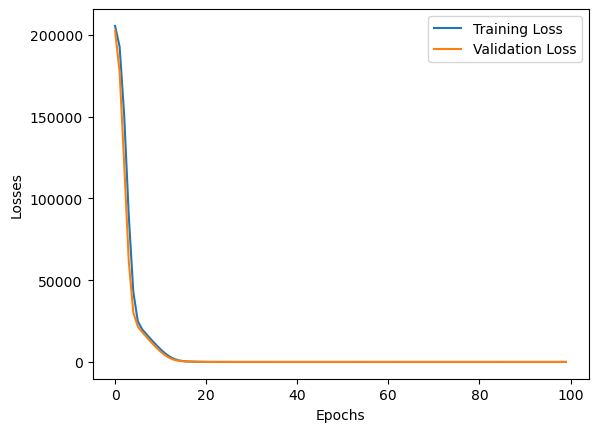

In [18]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({   # converting into dataframes
    "Training Loss" : train_losses,
    "Validation Loss"   : val_losses
})

plt.plot(loss_df["Training Loss"], label = "Training Loss")
plt.plot(loss_df["Validation Loss"], label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

In [19]:
# Loading the best model

model.load_state_dict(torch.load("best_model.pt")) # by using model.load_state_dict we are fitting inside the architecture , so that while now you run the model will be in best state.       

<All keys matched successfully>

In [20]:
# Evaluate the value (Global Evaluation)

model.eval()
with torch.no_grad():
    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tensor)

    train_mse_loss = criterion(train_preds, y_train_tensor)
    test_mse_loss = criterion(test_preds, y_test_tensor)

print("Training MSE:", train_mse_loss.item())
print("Testing MSE:", test_mse_loss.item())

Training MSE: 20.470481872558594
Testing MSE: 18.77337646484375


In [21]:
from sklearn.metrics import r2_score

print("r^2 score", r2_score(y_test, test_preds))

r^2 score 0.93439189680632


In [25]:
# Comparing all predicted values with the actual values.
predicted_df = pd.DataFrame(test_preds.numpy(), columns=["Predicted Values"])
actual_df = pd.DataFrame(y_test.values, columns=["Actual Values"])

pd.concat([predicted_df, actual_df], axis = 1)

,Predicted Values,Actual Values
0,435.360352,433.27
1,436.741699,438.16
2,461.097412,458.42
3,476.051178,480.82
4,435.043396,441.41
...,...,...
1909,451.414124,456.70
1910,431.555817,438.04
1911,467.753784,467.80
1912,430.911072,437.14
